# Compare Classical vs Quantum with make_moons

Make_moons is not linearly separable.

Classical needs no lineal activations, quantum need just entanglement.

# Data Loading

In [447]:
import pennylane as qml
from pennylane import numpy as pnp
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import time

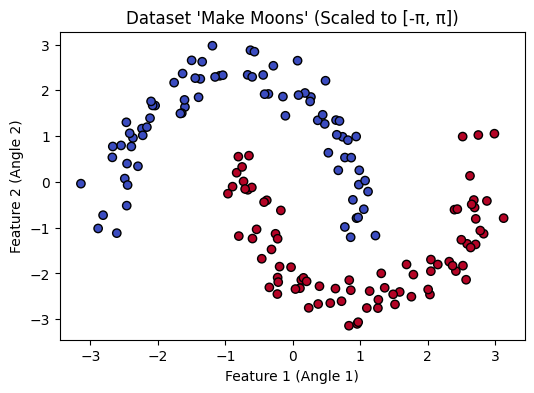

In [448]:
# Data Loading
X, y = make_moons(n_samples=200, noise=0.1, random_state=42) # 200 samples with a bit of noise

# Scale data to the interval [-π, π] to use as rotation angles
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_scaled = scaler.fit_transform(X)

# Train Test spliting
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# Dataset Visualization
plt.figure(figsize=(6, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Dataset 'Make Moons' (Scaled to [-π, π])")
plt.xlabel("Feature 1 (Angle 1)")
plt.ylabel("Feature 2 (Angle 2)")
plt.show()

# Define Models

Define a classical NN and a QNN

In [449]:
# Classical Pytorch NN
class ClassicalNN(nn.Module):
    def __init__(self):
        super(ClassicalNN, self).__init__()
        # Input: 2 features -> Hidden: 4 neurons -> Output: 1 probability
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid() # Squashes output to [0, 1]
        )

    def forward(self, x):
        return self.network(x)

In [450]:
# Quantum Neural Network (PennyLane + PyTorch)
n_qubits = 2
n_layers = 3 

# Standard simulator
dev = qml.device("default.qubit", wires=n_qubits)

# Define the Quantum Node
@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    # Embedding: Encode classical data into quantum states 
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # Ansatz: Basic trainable quantum layers with entanglement
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits)) # Just rotations in X
    
    # Measurement: Expected value in Z of the q0 (-1 to 1)
    return qml.expval(qml.PauliZ(0))

# Wrap QNode into a PyTorch Module
class QuantumNN(nn.Module):
    def __init__(self):
        super(QuantumNN, self).__init__()
        # Specify the shape of the weights for BasicEntanglerLayers
        weight_shapes = {"weights": (n_layers, n_qubits)}
        
        # qml.qnn.TorchLayer seamlessly integrates PennyLane with PyTorch
        self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)

    def forward(self, x):
        # QNode outputs values in [-1, 1]
        out = self.qlayer(x)
        
        # Add a view to ensure shape is (batch_size, 1)
        prob = ((out + 1.0) / 2.0).view(-1, 1) # Map [-1, 1] to [0, 1] to treat it as a probability
        return prob

In [451]:
# Instantiate both models
model_classical = ClassicalNN()
model_quantum = QuantumNN()

print("Models created successfully!")
print(f"Classical params: {sum(p.numel() for p in model_classical.parameters())}")
print(f"Quantum params: {sum(p.numel() for p in model_quantum.parameters())}")

Models created successfully!
Classical params: 17
Quantum params: 6


# Training Loop

In [452]:
# Training function
def train_model(model, X_train, y_train, epochs=100, lr=0.05):

    loss_fn = nn.BCELoss() # Binary Cross Entropy for binary classification
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam Optimizer
    
    loss_history =[]
    
    model.train() # Set model to training mode
    for epoch in range(epochs):
        # Clear previous gradients
        optimizer.zero_grad()
        
        # Forward
        predictions = model(X_train)
        
        # Calculate Loss
        loss = loss_fn(predictions, y_train)
        
        # Calculate gradients
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Save loss for plotting
        loss_history.append(loss.item())
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} | Loss: {loss.item():.4f}")
            
    return loss_history

# Evaluating Function
def evaluate_model(model, X_test, y_test):

    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient tracking to save memory
        predictions = model(X_test)

        # Convert probabilities to binary classes
        predicted_classes = (predictions >= 0.5).float()
        
        # Calculate accuracy
        correct = (predicted_classes == y_test).sum().item()
        accuracy = correct / y_test.shape[0]
        
    return accuracy

In [453]:
epochs = 100
learning_rate = 0.1


# Train Classical Model
start_time = time.time()
loss_history_classical = train_model(model_classical, X_train_t, y_train_t, epochs, learning_rate)
classical_time = time.time() - start_time
print(f"Classical training finished in {classical_time:.4f} seconds.\n")

Epoch  10/100 | Loss: 0.4027
Epoch  20/100 | Loss: 0.3120
Epoch  30/100 | Loss: 0.2894
Epoch  40/100 | Loss: 0.2721
Epoch  50/100 | Loss: 0.2601
Epoch  60/100 | Loss: 0.2460
Epoch  70/100 | Loss: 0.2339
Epoch  80/100 | Loss: 0.2274
Epoch  90/100 | Loss: 0.2244
Epoch 100/100 | Loss: 0.2221
Classical training finished in 0.0744 seconds.



In [454]:
epochs = 100
learning_rate = 0.1

# Train Quantum Model
start_time = time.time()
loss_history_quantum = train_model(model_quantum, X_train_t, y_train_t, epochs, learning_rate)
quantum_time = time.time() - start_time
print(f"Quantum training finished in {quantum_time:.4f} seconds.\n")

Epoch  10/100 | Loss: 0.7195
Epoch  20/100 | Loss: 0.6946
Epoch  30/100 | Loss: 0.6761
Epoch  40/100 | Loss: 0.6409
Epoch  50/100 | Loss: 0.6372
Epoch  60/100 | Loss: 0.6314
Epoch  70/100 | Loss: 0.6308
Epoch  80/100 | Loss: 0.6303
Epoch  90/100 | Loss: 0.6303
Epoch 100/100 | Loss: 0.6303
Quantum training finished in 1.2068 seconds.



--- FINAL RESULTS (TEST ACCURACY) ---
Classical Model Accuracy: 87.5%
Quantum Model Accuracy:   72.5%


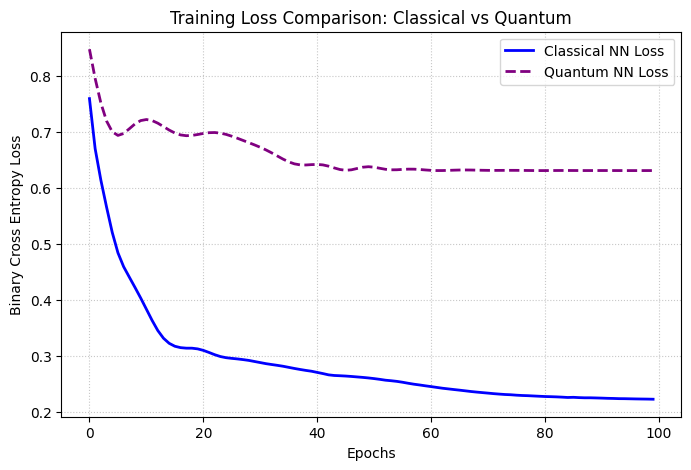

In [455]:
# Evaluation
acc_classical = evaluate_model(model_classical, X_test_t, y_test_t)
acc_quantum = evaluate_model(model_quantum, X_test_t, y_test_t)

print("--- FINAL RESULTS (TEST ACCURACY) ---")
print(f"Classical Model Accuracy: {acc_classical * 100:.1f}%")
print(f"Quantum Model Accuracy:   {acc_quantum * 100:.1f}%")

# Visualization of Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history_classical, label='Classical NN Loss', color='blue', linewidth=2)
plt.plot(loss_history_quantum, label='Quantum NN Loss', color='purple', linewidth=2, linestyle='--')
plt.title("Training Loss Comparison: Classical vs Quantum")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

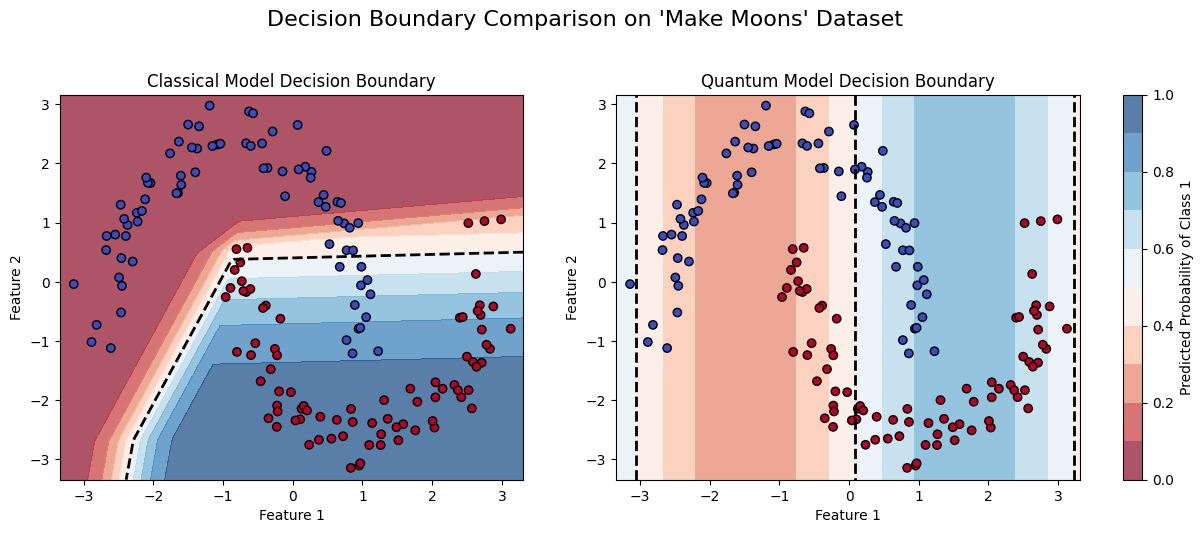

In [456]:
def plot_decision_boundaries(model_classical, model_quantum, X, y):
    """
    Plots the decision boundaries for both classical and quantum models side by side.
    """
    # Grid of points
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    
    # Meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Flatten the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # Get predictions from both models
    model_classical.eval()
    model_quantum.eval()
    
    with torch.no_grad():
        # Get probabilities and reshape them to the grid shape
        Z_classical = model_classical(grid_tensor).numpy().reshape(xx.shape)
        Z_quantum = model_quantum(grid_tensor).numpy().reshape(xx.shape)
        
    # Create the plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Classical Model
    contour1 = axes[0].contourf(xx, yy, Z_classical, levels=np.linspace(0, 1, 11), cmap='RdBu', alpha=0.7)
    axes[0].contour(xx, yy, Z_classical, levels=[0.5], colors='black', linestyles='dashed', linewidths=2)
    # Scatter the original training data
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    axes[0].set_title("Classical Model Decision Boundary")
    axes[0].set_xlabel("Feature 1")
    axes[0].set_ylabel("Feature 2")
    
    # Quantum Model
    contour2 = axes[1].contourf(xx, yy, Z_quantum, levels=np.linspace(0, 1, 11), cmap='RdBu', alpha=0.7)
    axes[1].contour(xx, yy, Z_quantum, levels=[0.5], colors='black', linestyles='dashed', linewidths=2)
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    axes[1].set_title("Quantum Model Decision Boundary")
    axes[1].set_xlabel("Feature 1")
    axes[1].set_ylabel("Feature 2")
    
    # Colorbar
    cbar = fig.colorbar(contour1, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Predicted Probability of Class 1')
    
    plt.suptitle("Decision Boundary Comparison on 'Make Moons' Dataset", fontsize=16, y=1.05)
    plt.show()

plot_decision_boundaries(model_classical, model_quantum, X_train, y_train)

As we can see here, the quantum model doesn't have the enough tools to rotate and draw complex curves

To improve this we will apply Rotations in more exes, reduce learning rate and re-upload data in each layer of the training

In [457]:
# Improved QNN

n_qubits = 2
n_layers = 4 # more layers for more expressivity

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode_improved(inputs, weights):

    # Embed data for before every layer instead of once
    for i in range(n_layers):
        # Re-upload classical data
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        
        # More complex Layers -> rotations in (X, Y, Z) per wire
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(n_qubits)) 
        
    return qml.expval(qml.PauliZ(0))

class QuantumNN_Improved(nn.Module):
    def __init__(self):
        super(QuantumNN_Improved, self).__init__()
        
        # StronglyEntanglingLayers requires a shape of (n_layers, n_qubits, 3)
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        
        self.qlayer = qml.qnn.TorchLayer(qnode_improved, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        # Map expectation value [-1, 1] to probability [0, 1]
        prob = ((out + 1.0) / 2.0).view(-1, 1) 
        return prob

# Instantiate the new powerful model
model_quantum = QuantumNN_Improved()

print("Improved Quantum Model created!")
print(f"New Quantum params: {sum(p.numel() for p in model_quantum.parameters())}")

Improved Quantum Model created!
New Quantum params: 24


In [458]:
epochs = 100
learning_rate = 0.05

# Train Quantum Model
start_time = time.time()
loss_history_quantum = train_model(model_quantum, X_train_t, y_train_t, epochs, learning_rate)
quantum_time = time.time() - start_time
print(f"Quantum training finished in {quantum_time:.4f} seconds.\n")

Epoch  10/100 | Loss: 0.2196
Epoch  20/100 | Loss: 0.1969
Epoch  30/100 | Loss: 0.1484
Epoch  40/100 | Loss: 0.1291
Epoch  50/100 | Loss: 0.1247
Epoch  60/100 | Loss: 0.1214
Epoch  70/100 | Loss: 0.1207
Epoch  80/100 | Loss: 0.1204
Epoch  90/100 | Loss: 0.1202
Epoch 100/100 | Loss: 0.1202
Quantum training finished in 1.6606 seconds.



--- FINAL RESULTS (TEST ACCURACY) ---
Classical Model Accuracy: 87.5%
Quantum Model Accuracy:   97.5%


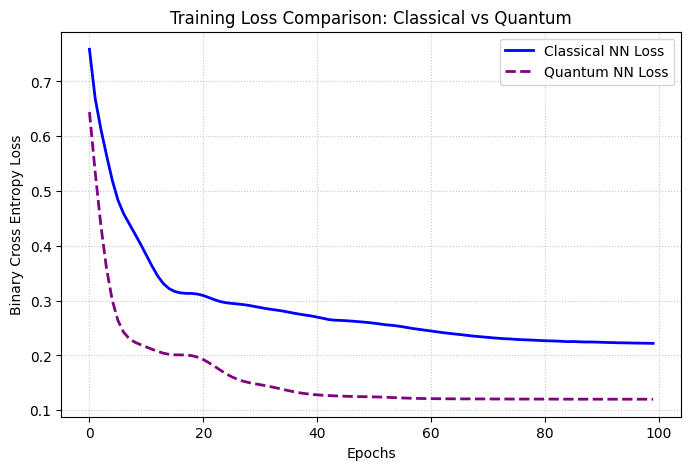

In [459]:
# Evaluation
acc_classical = evaluate_model(model_classical, X_test_t, y_test_t)
acc_quantum = evaluate_model(model_quantum, X_test_t, y_test_t)

print("--- FINAL RESULTS (TEST ACCURACY) ---")
print(f"Classical Model Accuracy: {acc_classical * 100:.1f}%")
print(f"Quantum Model Accuracy:   {acc_quantum * 100:.1f}%")

# Visualization of Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history_classical, label='Classical NN Loss', color='blue', linewidth=2)
plt.plot(loss_history_quantum, label='Quantum NN Loss', color='purple', linewidth=2, linestyle='--')
plt.title("Training Loss Comparison: Classical vs Quantum")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

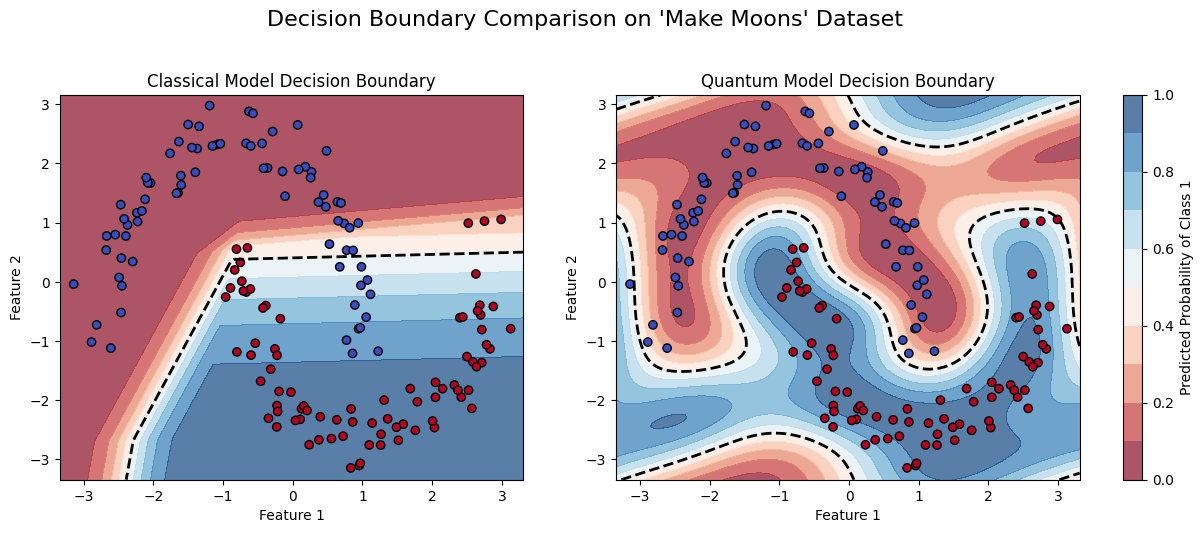

In [460]:
plot_decision_boundaries(model_classical, model_quantum, X_train, y_train)

As we can see here, the decision boundary is more complex now that the layers have the possibility to rotate in more axes

The accuracy has improved a lot compared to the basic quantum model and surpassed the classical model in accuracy 

Anyway, the quantum model reaches very fast to a Barren Plateau as we see in the Loss Plot, as this is one of the main issues of QML

It is also important to mention that the quantum model lasted more time training than the classical model in this case, because we are using a simulator